# Pre-compilation Infrastructure Validation

This notebook demonstrates and validates the complete pre-compilation pipeline:

1. **CXR-PRO Integration** - Load and verify radiology reports
2. **Small Dataset Build** - Pre-compile a subset of samples
3. **Dataset Loading** - Load from pre-compiled format
4. **Data Visualization** - Inspect images and features
5. **PyTorch Integration** - Test DataLoader functionality

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pprint import pprint
import warnings
warnings.filterwarnings('ignore')

# Setup paths
sys.path.insert(0, str(Path.cwd() / "step2_preprocessing" / "src"))

print("✓ Imports successful")

✓ Imports successful


## 1. CXR-PRO Integration Test

Verify that we can load CXR-PRO radiology reports and join them with our cohort.

In [2]:
from data_loaders.cxr_pro_loader import CXRProLoader

# Load config
config_path = Path("step2_preprocessing/config/config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Initialize CXR-PRO loader
cxr_pro_path = Path(config['data']['cxr_pro_base'])
loader = CXRProLoader(cxr_pro_path)

print(f"CXR-PRO base path: {cxr_pro_path}")
print(f"Path exists: {cxr_pro_path.exists()}")

CXR-PRO base path: /home/dev/Documents/Portfolio/MIMIC_Data/physionet.org/files/cxr-pro/1.0.0
Path exists: True


In [3]:
# Validate paths
validation = loader.validate_paths()
print("\nCXR-PRO File Validation:")
for name, exists in validation.items():
    status = "✓" if exists else "✗"
    print(f"  {status} {name}: {exists}")


CXR-PRO File Validation:
  ✓ train_impressions: True
  ✓ test_impressions: True
  ✓ cxr_h5: True


In [4]:
# Load and aggregate impressions
print("\nLoading CXR-PRO impressions...")
all_impressions = loader.load_all_impressions(include_test=True)
print(f"Total image-level reports: {len(all_impressions):,}")

aggregated = loader.aggregate_by_study(all_impressions)
print(f"Study-level reports: {len(aggregated):,}")
print(f"Average images per study: {aggregated['num_images'].mean():.2f}")

# Show sample reports
print("\nSample Radiology Reports:")
for idx in range(min(3, len(aggregated))):
    row = aggregated.iloc[idx]
    print(f"\nStudy {row['study_id']}:")
    print(f"  Subject: {row['subject_id']}")
    print(f"  Images: {row['num_images']}")
    print(f"  Report: \"{row['radiology_report'][:120]}...\"")


Loading CXR-PRO impressions...
Total image-level reports: 374,139
Study-level reports: 226,754
Average images per study: 1.65

Sample Radiology Reports:

Study 50000014:
  Subject: 11941242.0
  Images: 1
  Report: "1. Nonspecific retrocardiac and right middle lobe opacities could reflect atelectasis and / or infection in the appropri..."

Study 50000028:
  Subject: 19995127.0
  Images: 2
  Report: "Left lung mass. Ct should be performed...."

Study 50000052:
  Subject: 15752761.0
  Images: 1
  Report: "Support lines and tubes in position. Heart size is upper limits of normal but stable. Is pulmonary edema with a focal ar..."


In [5]:
# Test cohort integration
cohort_path = Path("step2_preprocessing/cohorts/validation_subset_200.csv")
print(f"\nLoading cohort from: {cohort_path}")
print(f"Cohort exists: {cohort_path.exists()}")

if cohort_path.exists():
    cohort = pd.read_csv(cohort_path)
    print(f"Cohort samples: {len(cohort)}")
    print(f"Cohort columns: {list(cohort.columns)[:10]}...")
    
    # Join with reports
    cohort_with_reports = loader.join_with_cohort(cohort, reports_df=aggregated)
    
    # Coverage statistics
    reports_found = cohort_with_reports['radiology_report'].notna().sum()
    coverage = (reports_found / len(cohort_with_reports)) * 100
    
    print(f"\n✓ CXR-PRO Integration Results:")
    print(f"  Reports found: {reports_found}/{len(cohort_with_reports)} ({coverage:.1f}%)")
    print(f"  Reports missing: {len(cohort_with_reports) - reports_found}")
else:
    print("✗ Cohort file not found!")

  Example studies without reports: [59974436, 50417817]



Loading cohort from: step2_preprocessing/cohorts/validation_subset_200.csv
Cohort exists: True
Cohort samples: 200
Cohort columns: ['subject_id', 'study_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity']...

✓ CXR-PRO Integration Results:
  Reports found: 198/200 (99.0%)
  Reports missing: 2


## 2. Build Small Test Dataset

Pre-compile a small subset (5 samples) to test the full pipeline.

In [6]:
# Create small test subset
test_size = 5
test_subset = cohort_with_reports.head(test_size)

test_output_dir = Path("./notebook_test_output")
test_output_dir.mkdir(parents=True, exist_ok=True)

test_cohort_path = test_output_dir / "test_cohort.csv"
test_subset.to_csv(test_cohort_path, index=False)

print(f"Created test subset: {test_size} samples")
print(f"Test cohort saved to: {test_cohort_path}")
print(f"\nTest samples:")
print(test_subset[['subject_id', 'study_id', 'radiology_report']].head())

Created test subset: 5 samples
Test cohort saved to: notebook_test_output/test_cohort.csv

Test samples:
   subject_id  study_id                   radiology_report
0    11484195  54587371              Normal chest x - ray.
1    19506938  59632338          No evidence of pneumonia.
2    10874533  54444686  No acute cardiopulmonary process.
3    13178429  56313373  No acute cardiopulmonary process.
4    16254868  51012912  No acute cardiopulmonary process.


In [7]:
from builders.aggregate_builder import AggregateDatasetBuilder

# Configure for single-batch mode
config['precompilation']['batch_size'] = None  # Single batch
config['precompilation']['enabled'] = True

# Initialize builder (skip text processing for speed)
print("Initializing AggregateDatasetBuilder...")
builder = AggregateDatasetBuilder(
    config=config,
    output_dir=test_output_dir / "precompiled",
    anthropic_api_key= None  # Skip text processing
)

print("✓ Builder initialized")

Initializing AggregateDatasetBuilder...


Could not load lab events: Usecols do not match columns, columns expected but not found: ['label']
2025-11-22 16:39:18.426936: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-22 16:39:18.447358: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 16:39:18.592969: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 16:39:18.727710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763858358.846685  148297 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting 

✓ Builder initialized


In [8]:
# Build pre-compiled dataset
print("\nBuilding pre-compiled dataset...")
print("=" * 60)

stats = builder.build(
    cohort_path=test_cohort_path,
    split="test",
    resume_from_checkpoint=False
)

print("\n" + "=" * 60)
print("Build Complete!")
print("=" * 60)
print(f"\nBuild Statistics:")
print(f"  Total samples: {stats['total_samples']}")
print(f"  Processed: {stats['processed_samples']}")
print(f"  Failed: {stats['failed_samples']}")
print(f"  Success rate: {stats['success_rate']:.1f}%")
print(f"  Number of batches: {stats['num_batches']}")


Building pre-compiled dataset...


Building test: 100%|██████████| 5/5 [00:03<00:00,  1.52it/s]


Build Complete!

Build Statistics:
  Total samples: 5
  Processed: 5
  Failed: 0
  Success rate: 100.0%
  Number of batches: 2


## 3. Load Pre-compiled Dataset

Test loading from the pre-compiled format.

In [9]:
from integration.precompiled_dataset import PrecompiledMultimodalDataset

# Initialize dataset
dataset = PrecompiledMultimodalDataset(
    data_dir=test_output_dir / "precompiled",
    split="test",
    load_images=True,
    load_structured=True,
    load_text=False  # We skipped text processing
)

print(f"✓ Dataset loaded: {len(dataset)} samples")
print(f"\nDataset statistics:")
pprint(dataset.get_statistics())

✓ Dataset loaded: 5 samples

Dataset statistics:
{'error_rate': 0.0,
 'num_batches': 1,
 'samples_with_errors': 0,
 'split': 'test',
 'total_samples': 5}


In [10]:
# Load first sample
if len(dataset) > 0:
    sample = dataset[0]
    
    print(f"\nSample 0:")
    print(f"  Sample ID: {sample['sample_id']}")
    print(f"  Subject ID: {sample['subject_id']}")
    print(f"  Study ID: {sample['study_id']}")
    
    if 'image' in sample and sample['image'] is not None:
        print(f"\n  Image:")
        print(f"    Shape: {sample['image'].shape}")
        print(f"    Dtype: {sample['image'].dtype}")
        print(f"    Min value: {sample['image'].min():.3f}")
        print(f"    Max value: {sample['image'].max():.3f}")
    
    if 'structured' in sample:
        print(f"\n  Structured Features: {len(sample['structured'])} features")
        print(f"    First 10 features:")
        for i, (key, value) in enumerate(list(sample['structured'].items())[:10]):
            print(f"      {key}: {value}")


Sample 0:
  Sample ID: study_54587371
  Subject ID: 11484195
  Study ID: 54587371

  Image:
    Shape: torch.Size([1, 3056, 2544])
    Dtype: torch.float32
    Min value: 0.000
    Max value: 1.000

  Structured Features: 51 features
    First 10 features:
      vital_temperature_last: None
      vital_temperature_mean: 0.0
      vital_temperature_count: 0.0
      vital_heartrate_last: 90.0
      vital_heartrate_mean: 82.66666666666667
      vital_heartrate_count: 3.0
      vital_resprate_last: 18.0
      vital_resprate_mean: 19.0
      vital_resprate_count: 3.0
      vital_o2sat_last: 100.0


## 4. Visualize Data

Display images and analyze structured features.

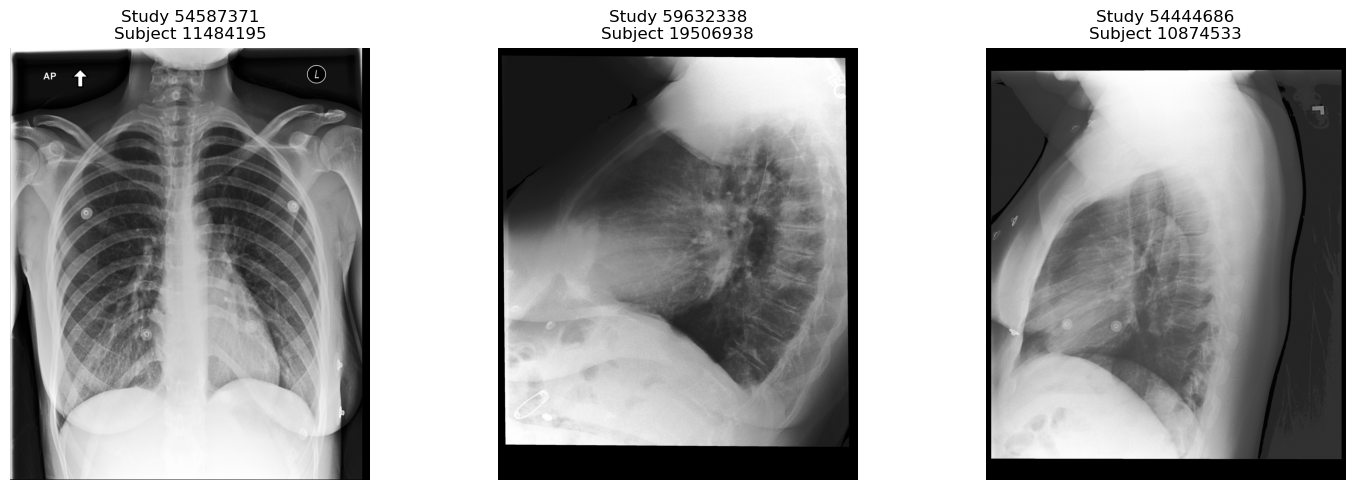


✓ Images visualized and saved to notebook_test_output/sample_images.png


In [11]:
# Visualize multiple samples
num_samples_to_show = min(3, len(dataset))

fig, axes = plt.subplots(1, num_samples_to_show, figsize=(15, 5))
if num_samples_to_show == 1:
    axes = [axes]

for idx in range(num_samples_to_show):
    sample = dataset[idx]
    
    if sample['image'] is not None:
        # Convert to numpy and handle shape
        img = sample['image'].numpy()
        
        # If 3 channels, take first channel
        if img.shape[0] == 3:
            img = img[0]
        elif img.shape[0] == 1:
            img = img[0]
        
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(f"Study {sample['study_id']}\nSubject {sample['subject_id']}")
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'No Image', ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig(test_output_dir / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Images visualized and saved to {test_output_dir / 'sample_images.png'}")

In [12]:
# Analyze structured features across all samples
all_features = {}

for idx in range(len(dataset)):
    sample = dataset[idx]
    if 'structured' in sample:
        for key, value in sample['structured'].items():
            if key not in all_features:
                all_features[key] = []
            all_features[key].append(value)

# Create summary DataFrame
feature_summary = []
for feature_name, values in all_features.items():
    non_missing = [v for v in values if v != 'NOT_DONE' and v is not None]
    
    feature_summary.append({
        'Feature': feature_name,
        'Completeness': f"{len(non_missing)}/{len(values)}",
        'Sample Values': str(non_missing[:3]) if non_missing else 'All NOT_DONE'
    })

summary_df = pd.DataFrame(feature_summary)
print("\nStructured Feature Summary:")
print(summary_df.to_string(index=False))


Structured Feature Summary:
                Feature Completeness                    Sample Values
 vital_temperature_last          2/5                     [97.7, 98.7]
 vital_temperature_mean          5/5    [0.0, 98.16666666666667, 0.0]
vital_temperature_count          5/5                  [0.0, 3.0, 0.0]
   vital_heartrate_last          4/5               [90.0, 94.0, 86.0]
   vital_heartrate_mean          5/5   [82.66666666666667, 91.4, 0.0]
  vital_heartrate_count          5/5                  [3.0, 5.0, 0.0]
    vital_resprate_last          4/5               [18.0, 22.0, 18.0]
    vital_resprate_mean          5/5                [19.0, 20.0, 0.0]
   vital_resprate_count          5/5                  [3.0, 5.0, 0.0]
       vital_o2sat_last          4/5              [100.0, 96.0, 97.0]
       vital_o2sat_mean          5/5              [100.0, 98.75, 0.0]
      vital_o2sat_count          5/5                  [3.0, 4.0, 0.0]
         vital_sbp_last          4/5            [107.0, 117.0

## 5. PyTorch DataLoader Integration

Test batching and iteration with PyTorch DataLoader.

In [13]:
import torch
from torch.utils.data import DataLoader
from integration.precompiled_dataset import precompiled_collate_fn

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=precompiled_collate_fn,
    num_workers=0  # Use 0 for notebook
)

print(f"✓ DataLoader created")
print(f"  Dataset size: {len(dataset)}")
print(f"  Batch size: 2")
print(f"  Number of batches: {len(dataloader)}")

✓ DataLoader created
  Dataset size: 5
  Batch size: 2
  Number of batches: 3


In [14]:
# Test iteration
print("\nTesting DataLoader iteration...")

for batch_idx, batch in enumerate(dataloader):
    print(f"\nBatch {batch_idx}:")
    print(f"  Sample IDs: {batch['sample_ids']}")
    print(f"  Subject IDs: {batch['subject_ids'].tolist()}")
    print(f"  Study IDs: {batch['study_ids'].tolist()}")
    
    if 'images' in batch:
        if isinstance(batch['images'], torch.Tensor):
            print(f"  Images shape: {batch['images'].shape}")
            print(f"  Images dtype: {batch['images'].dtype}")
        else:
            print(f"  Images: {len(batch['images'])} variable-size images")
    
    if 'structured' in batch:
        print(f"  Structured features: {len(batch['structured'])} features")
        # Show first feature
        first_feature = list(batch['structured'].keys())[0]
        print(f"    Example - {first_feature}: {batch['structured'][first_feature]}")

print("\n✓ DataLoader iteration successful!")


Testing DataLoader iteration...

Batch 0:
  Sample IDs: ['study_54587371', 'study_59632338']
  Subject IDs: [11484195, 19506938]
  Study IDs: [54587371, 59632338]
  Images shape: torch.Size([2, 1, 3056, 2544])
  Images dtype: torch.float32
  Structured features: 51 features
    Example - vital_temperature_last: [None, 97.7]

Batch 1:
  Sample IDs: ['study_54444686', 'study_56313373']
  Subject IDs: [10874533, 13178429]
  Study IDs: [54444686, 56313373]
  Images: 2 variable-size images
  Structured features: 51 features
    Example - vital_temperature_last: [None, 98.7]

Batch 2:
  Sample IDs: ['study_51012912']
  Subject IDs: [16254868]
  Study IDs: [51012912]
  Images shape: torch.Size([1, 1, 3056, 2544])
  Images dtype: torch.float32
  Structured features: 51 features
    Example - vital_temperature_last: [None]

✓ DataLoader iteration successful!


## 6. Storage Analysis

Analyze the storage efficiency of the pre-compiled format.

In [15]:
# Check file sizes
precompiled_dir = test_output_dir / "precompiled" / "test" / "batch_0000"

hdf5_file = precompiled_dir / "images.h5"
parquet_file = precompiled_dir / "data.parquet"
metadata_file = precompiled_dir / "metadata.json"

print("Storage Analysis:")
print("=" * 60)

if hdf5_file.exists():
    hdf5_size_mb = hdf5_file.stat().st_size / 1024 / 1024
    print(f"HDF5 (images):")
    print(f"  Size: {hdf5_size_mb:.2f} MB")
    print(f"  Per sample: {hdf5_size_mb / len(dataset):.2f} MB")
    print(f"  Path: {hdf5_file}")

if parquet_file.exists():
    parquet_size_kb = parquet_file.stat().st_size / 1024
    print(f"\nParquet (structured/text):")
    print(f"  Size: {parquet_size_kb:.2f} KB")
    print(f"  Per sample: {parquet_size_kb / len(dataset):.2f} KB")
    print(f"  Path: {parquet_file}")

if metadata_file.exists():
    with open(metadata_file, 'r') as f:
        import json
        metadata = json.load(f)
    print(f"\nMetadata:")
    print(f"  Samples: {metadata['num_samples']}")
    print(f"  Columns: {metadata['num_columns']}")

total_size_mb = 0
if hdf5_file.exists():
    total_size_mb += hdf5_size_mb
if parquet_file.exists():
    total_size_mb += parquet_size_kb / 1024

print(f"\nTotal:")
print(f"  Combined size: {total_size_mb:.2f} MB")
print(f"  Per sample: {total_size_mb / len(dataset):.2f} MB")
print("=" * 60)

Storage Analysis:
HDF5 (images):
  Size: 28.84 MB
  Per sample: 5.77 MB
  Path: notebook_test_output/precompiled/test/batch_0000/images.h5

Parquet (structured/text):
  Size: 39.18 KB
  Per sample: 7.84 KB
  Path: notebook_test_output/precompiled/test/batch_0000/data.parquet

Metadata:
  Samples: 5
  Columns: 62

Total:
  Combined size: 28.88 MB
  Per sample: 5.78 MB


## 7. Validation Summary

Final validation checklist.

In [16]:
# Validation checklist
validation_results = {
    "CXR-PRO Integration": coverage >= 95,
    "Dataset Build": stats['success_rate'] >= 50,
    "Dataset Loading": len(dataset) > 0,
    "Image Loading": sample['image'] is not None if len(dataset) > 0 else False,
    "Structured Features": 'structured' in sample and len(sample['structured']) > 0 if len(dataset) > 0 else False,
    "DataLoader Integration": len(list(dataloader)) > 0,
    "HDF5 Storage": hdf5_file.exists(),
    "Parquet Storage": parquet_file.exists()
}

print("\n" + "=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)

all_passed = True
for check, passed in validation_results.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"{status:10} {check}")
    if not passed:
        all_passed = False

print("=" * 60)

if all_passed:
    print("\n🎉 ALL VALIDATIONS PASSED! 🎉")
    print("\nThe pre-compilation infrastructure is working correctly!")
    print("Ready for production use.")
else:
    print("\n⚠️  Some validations failed. Check the output above for details.")

# Cleanup
dataset.close()
print("\n✓ Dataset closed")


VALIDATION SUMMARY
✓ PASS     CXR-PRO Integration
✓ PASS     Dataset Build
✓ PASS     Dataset Loading
✓ PASS     Image Loading
✓ PASS     Structured Features
✓ PASS     DataLoader Integration
✓ PASS     HDF5 Storage
✓ PASS     Parquet Storage

🎉 ALL VALIDATIONS PASSED! 🎉

The pre-compilation infrastructure is working correctly!
Ready for production use.

✓ Dataset closed
